# Claim Severity Prediction (Risk Model)

### Import Required Libraries

In [1]:
import sys 
import os

sys.path.insert(0, os.path.abspath('C:/Users/dagic/OneDrive/Documents/KAIM/Week_3/insurance-risk-analytics/src'))

print('Path set. Python will now look in:', os.path.abspath('C:/Users/dagic/OneDrive/Documents/KAIM/Week_3/insurance-risk-analytics'))

Path set. Python will now look in: C:\Users\dagic\OneDrive\Documents\KAIM\Week_3\insurance-risk-analytics


In [2]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
import joblib


from data_loader import load_data
from data_preprocessor import num_impute, cat_impute, scaler
from train_test_split import train_test_split
import model_classifier as m
import shap_analysis as sa

c:\Users\dagic\OneDrive\Documents\KAIM\Week_3\insurance-risk-analytics\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### load the dataset

In [3]:
df = load_data('../data/processed/cleaned_insurance_data.csv')

df.head()

C:\Users\dagic\OneDrive\Documents\KAIM\Week_3\insurance-risk-analytics\src\data_loader.py:15: DtypeWarning: Columns (0: MaritalStatus, 1: Gender, 2: CapitalOutstanding, 3: CrossBorder) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, **kwargs)


Dataset loaded successfully.
Shape: (1000098, 52)


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


## Data preparation

### Handling Missing Values by Imputation

In [4]:
if 'CapitalOutstanding' in df.columns:
    df['CapitalOutstanding'] = pd.to_numeric(df['CapitalOutstanding'], errors='coerce')

# 3. Handle the very last NaN column (NumberOfVehiclesInFleet)
# Missing fleet count usually means 0 (not part of a fleet)
if 'NumberOfVehiclesInFleet' in df.columns:
    df['NumberOfVehiclesInFleet'] = df['NumberOfVehiclesInFleet'].fillna(0)

In [5]:
numerical_cols = ['PolicyID','mmcode', 'Cylinders', 'cubiccapacity', 'kilowatts', 'NumberOfDoors', 'CustomValueEstimate', 'CapitalOutstanding',
                   'SumInsured', 'CalculatedPremiumPerTerm', 'TotalPremium', 'TotalClaims']

for col in numerical_cols:
    df[col] = pd.to_numeric(df[col],errors='coerce')

print(df[numerical_cols].dtypes)

PolicyID                      int64
mmcode                      float64
Cylinders                   float64
cubiccapacity               float64
kilowatts                   float64
NumberOfDoors               float64
CustomValueEstimate         float64
CapitalOutstanding          float64
SumInsured                  float64
CalculatedPremiumPerTerm    float64
TotalPremium                float64
TotalClaims                 float64
dtype: object


In [6]:
df = num_impute(df, numerical_cols)

In [7]:
print(df.columns.tolist())

['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth', 'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language', 'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province', 'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode', 'VehicleType', 'RegistrationYear', 'make', 'Model', 'Cylinders', 'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors', 'VehicleIntroDate', 'CustomValueEstimate', 'AlarmImmobiliser', 'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'WrittenOff', 'Rebuilt', 'Converted', 'CrossBorder', 'NumberOfVehiclesInFleet', 'SumInsured', 'TermFrequency', 'CalculatedPremiumPerTerm', 'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section', 'Product', 'StatutoryClass', 'StatutoryRiskType', 'TotalPremium', 'TotalClaims']


In [8]:
categorical_cols = ['Gender','Province','VehicleType','CoverType','make','MaritalStatus', 'Bank', 'AccountType', 'Model', 'bodytype']

df = cat_impute(df, categorical_cols)
print(df[categorical_cols].dtypes)

Gender           str
Province         str
VehicleType      str
CoverType        str
make             str
MaritalStatus    str
Bank             str
AccountType      str
Model            str
bodytype         str
dtype: object


In [9]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

In [10]:
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

In [12]:
zero_fill_cols = ['NewVehicle', 'WrittenOff', 'Rebuilt', 'Converted', 'CrossBorder', 'NumberOfVehiclesInFleet']
existing_cols = [col for col in zero_fill_cols if col in df.columns]
if existing_cols:
    df[existing_cols] = df[existing_cols].fillna(0)

In [13]:
print(df.columns.tolist())

['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth', 'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language', 'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province', 'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode', 'VehicleType', 'RegistrationYear', 'make', 'Model', 'Cylinders', 'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors', 'VehicleIntroDate', 'CustomValueEstimate', 'AlarmImmobiliser', 'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'WrittenOff', 'Rebuilt', 'Converted', 'CrossBorder', 'NumberOfVehiclesInFleet', 'SumInsured', 'TermFrequency', 'CalculatedPremiumPerTerm', 'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section', 'Product', 'StatutoryClass', 'StatutoryRiskType', 'TotalPremium', 'TotalClaims']


## Feature Engineering

In [14]:
df['VehicleAge'] = (2025 - df['RegistrationYear'])
if 'VehicleIntroDate' in df.columns:
    df = df.drop(columns=['VehicleIntroDate'])

In [15]:
all_categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

C:\Users\dagic\AppData\Local\Temp\ipykernel_18756\2309419677.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  all_categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


In [16]:
df['Margin'] = (df['TotalPremium'] -df['TotalClaims'])

In [17]:
df['HasClaim'] = (df['TotalClaims'] > 0).astype(int)

In [18]:

df.head()

,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims,VehicleAge,Margin,HasClaim
0,145249,12827.0,2015-03-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0,21,21.929825,0
1,145249,12827.0,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0,21,21.929825,0
2,145249,12827.0,2015-07-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0,21,0.000000,0
3,145255,12827.0,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0,21,512.848070,0
4,145255,12827.0,2015-07-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0,21,0.000000,0


### One-hot Encoding 

In [19]:
df_encoded = pd.get_dummies(df,columns=all_categorical_cols,drop_first=True)

In [20]:
columns_scaler = ['TotalClaims']
df_scaled = scaler('minMaxScaler', df_encoded, columns_scaler)
df_scaled

,UnderwrittenCoverID,PolicyID,IsVATRegistered,PostalCode,mmcode,RegistrationYear,Cylinders,cubiccapacity,kilowatts,NumberOfDoors,...,CoverGroup_Standalone passenger liability,CoverGroup_Third Party Only,CoverGroup_Trailer,Section_Motor Comprehensive,Section_Optional Extended Covers,Section_Standalone passenger liability,"Section_Third party or third party, fire and theft only",Product_Mobility Commercial Cover: Monthly,Product_Mobility Metered Taxis: Monthly,Product_Standalone Passenger Liability
0,145249,12827.0,True,1459,44069150.0,2004,6.0,2597.0,130.0,4.0,...,False,False,False,True,False,False,False,False,True,False
1,145249,12827.0,True,1459,44069150.0,2004,6.0,2597.0,130.0,4.0,...,False,False,False,True,False,False,False,False,True,False
2,145249,12827.0,True,1459,44069150.0,2004,6.0,2597.0,130.0,4.0,...,False,False,False,True,False,False,False,False,True,False
3,145255,12827.0,True,1459,44069150.0,2004,6.0,2597.0,130.0,4.0,...,False,False,False,True,False,False,False,False,True,False
4,145255,12827.0,True,1459,44069150.0,2004,6.0,2597.0,130.0,4.0,...,False,False,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1000093,31520,389.0,False,7493,4614100.0,2013,4.0,2693.0,110.0,4.0,...,False,False,False,True,False,False,False,True,False,False
1000094,31520,389.0,False,7493,4614100.0,2013,4.0,2693.0,110.0,4.0,...,False,False,False,True,False,False,False,True,False,False
1000095,31520,389.0,False,7493,4614100.0,2013,4.0,2693.0,110.0,4.0,...,False,False,False,True,False,False,False,True,False,False
1000096,31519,389.0,False,7493,4614100.0,2013,4.0,2693.0,110.0,4.0,...,False,False,False,True,False,False,False,True,False,False


## Train-Test Split

In [21]:
X = df_encoded.drop(columns=['TotalClaims', 'HasClaim'], errors='ignore')

y = df_encoded['HasClaim']

X_train, X_test, y_train, y_test = m.split_data(X, y)

In [ ]:
# Drop the date column for now if you aren't engineering features from it
if 'VehicleIntroDate' in X_train.columns:
    X_train = X_train.drop(columns=['VehicleIntroDate'])
    X_test = X_test.drop(columns=['VehicleIntroDate'])

# Catch remaining object/categorical columns with the mode
for col in X_train.select_dtypes(include=['object']).columns:
    mode_value = X_train[col].mode()[0] if not X_train[col].mode().empty else 'Unknown'
    X_train[col] = X_train[col].fillna(mode_value)
    X_test[col] = X_test[col].fillna(mode_value)

#Final sanity check safety net (for any remaining numeric columns)
X_train = X_train.fillna(X_train.median(numeric_only=True))
X_test = X_test.fillna(X_train.median(numeric_only=True))

# Verify it's perfectly clean
print("Remaining NaNs:", X_train.isna().sum().sum())

## Claim Severity Prediction Models

    -   Goal: Predict TotalClaims for policies that filed claims.

## Model Training

In [ ]:
# Check for NaNs in your training features
print("--- Missing values in X_train ---")
print(X_train.isna().sum()[X_train.isna().sum() > 0])

print("\n--- Missing values in y_train ---")
print(y_train.isna().sum())

--- Missing values in X_train ---
Series([], dtype: int64)

--- Missing values in y_train ---
0


In [ ]:
X_train.columns[X_train.columns.duplicated()]

Index([], dtype='str')

In [ ]:
X_test = X_test.loc[:, ~X_test.columns.duplicated()]

In [ ]:
X_train.select_dtypes(include=['object']).columns

Index([], dtype='str')

In [ ]:
X_train.select_dtypes(include=['datetime']).columns

Index([], dtype='str')

In [ ]:
# List of raw text columns to drop before training
cols_to_drop = ['VehicleIntroDate']

for col in cols_to_drop:
    if col in X_train.columns:
        X_train = X_train.drop(columns=[col])
        X_test = X_test.drop(columns=[col])


In [ ]:
lr_model, rfc_model, xgb_model = m.train_models(X_train, y_train)

c:\Users\dagic\OneDrive\Documents\KAIM\Week_3\insurance-risk-analytics\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Model Evaluation

In [ ]:
models = ['Logistic Regression', 'Random Forest', 'XGBoost']

accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

In [ ]:
# Prints the performance of each model so we can compare them.
for model in [lr_model, rfc_model, xgb_model]:

    accuracy, precision, recall, f1, _ = m.evaluate_model(
        model,
        X_test,
        y_test
    )

    accuracy_scores.append(accuracy)

    precision_scores.append(precision)

    recall_scores.append(recall)

    f1_scores.append(f1)


In [ ]:
# Print evaluation results
for i, model_name in enumerate(models):

    print(f"Evaluation results for {model_name}:")

    print(f" - Accuracy Score: {accuracy_scores[i]:.4f}")

    print(f" - Precision Score: {precision_scores[i]:.4f}")

    print(f" - Recall Score: {recall_scores[i]:.4f}")

    print(f" - F1 Score: {f1_scores[i]:.4f}")

    print("\n")

Evaluation results for Logistic Regression:
 - Accuracy Score: 0.9997
 - Precision Score: 1.0000
 - Recall Score: 0.8978
 - F1 Score: 0.9462


Evaluation results for Random Forest:
 - Accuracy Score: 0.9997
 - Precision Score: 1.0000
 - Recall Score: 0.8978
 - F1 Score: 0.9462


Evaluation results for XGBoost:
 - Accuracy Score: 1.0000
 - Precision Score: 1.0000
 - Recall Score: 1.0000
 - F1 Score: 1.0000




## Comparing Model Performance

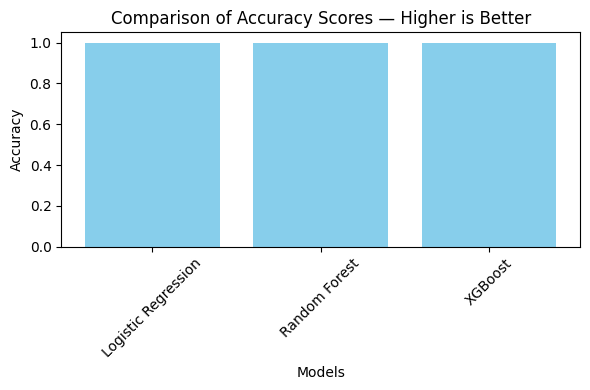

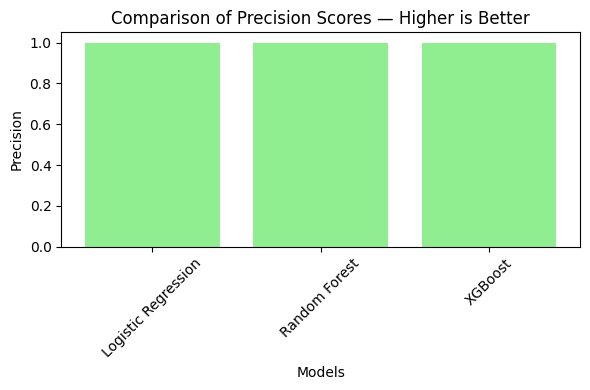

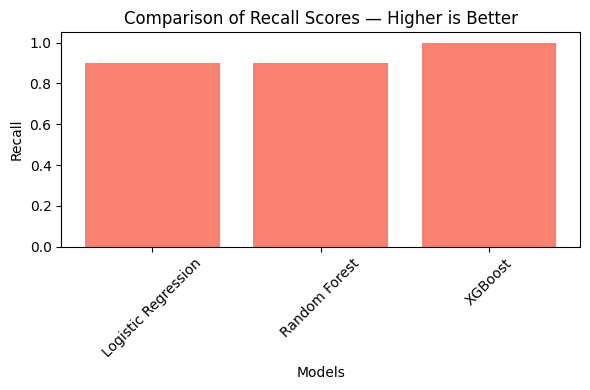

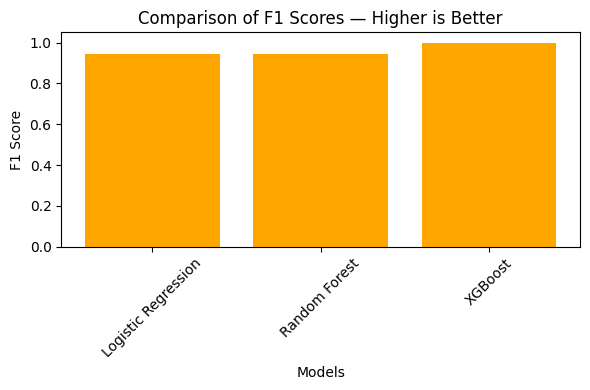

In [ ]:
# Plot metrics
m.plot_metrics(
    models,
    accuracy_scores,
    precision_scores,
    recall_scores,
    f1_scores
)

### Model Selection for Premium Optimization (Pricing Framework)

    -    As shown above Linear Regressiona dn Rando Forest achieved F1 score of 0.9462 which means that they never flag a a customer with no claim as a high risk claimant. 

    -   their recall is 89% which means they truely catches the 89% of all future claims.

    -   The XGBoost scored all the metrices to 1.0, This makes it the selected model for the pricing framework.

### Save your models to files

In [ ]:
# Save your models to files
xgb_model.save_model('xgb_model.json')

print("XGBoost model saved successfully!")



XGBoost model saved successfully!


## SHAP Analysis

In [ ]:
sa.shap_tree_explainer(xgb_model, X_test)

TypeError: 'module' object is not callable